# EDA

## Setup & Load Data

In [51]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap


Path("../results/figures").mkdir(parents=True, exist_ok=True)
Path("../results/tables").mkdir(parents=True, exist_ok=True)

In [52]:

rna = pd.read_csv("../data/processed/rna_pam50.csv").set_index("patient")
meth = pd.read_csv("../data/processed/meth_pam50_knn_imputed.csv", index_col=0)
meth_not_imp = pd.read_csv("../data/processed/meth_pam50.csv")
labels = pd.read_csv("../data/processed/labels_luminal_brca.csv").set_index("patient")
cpg_gene = pd.read_csv("../data/processed/cpg_gene_map.csv")

patients = rna.index.intersection(meth.index).intersection(labels.index)
rna = rna.loc[patients]
meth = meth.loc[patients]
labels = labels.loc[patients]
subtype = labels["subtype"]

print("Patients:", len(patients))
print(subtype.value_counts())

Patients: 563
subtype
LumA    422
LumB    141
Name: count, dtype: int64


In [53]:
# Prepare methylation data for visualizations: drop NA  and scale
meth_clean = meth.dropna(axis=1, how="all")
scaler_m = StandardScaler()
meth_scaled = scaler_m.fit_transform(meth_clean)

In [54]:
missing_cols = meth_not_imp.isna().any(axis=0).sum()
print(missing_cols)

168


## Methylation

### Check transformation: Beta vs M-value distribution

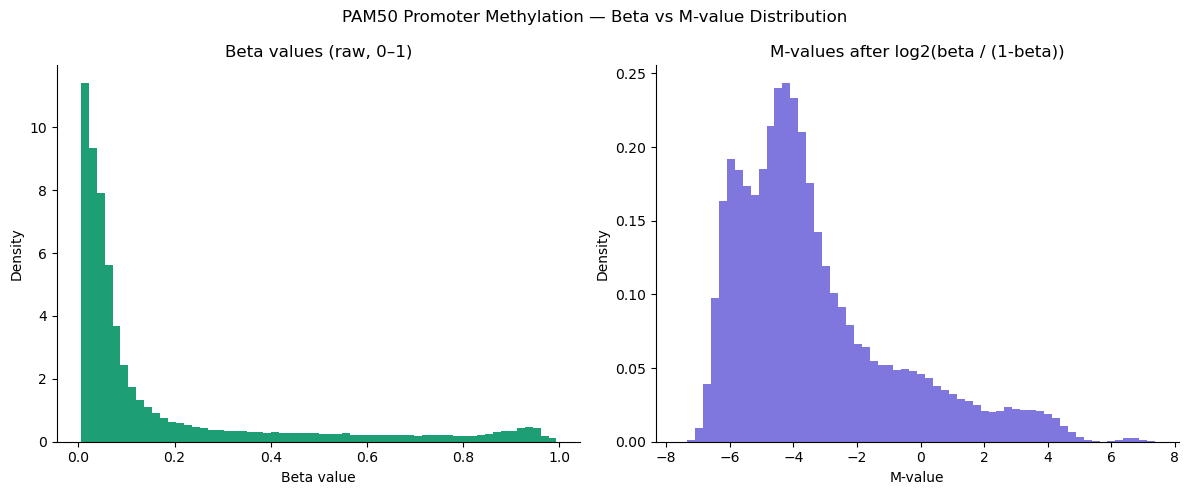

Beta: mean=0.171, std=0.246, range=[0.005, 0.994]
M:    mean=-3.329, std=2.552, range=[-7.587, 7.378]


In [55]:
# Beta vs M-value distribution
def beta_to_m(B):
    B = np.clip(B, 1e-4, 1 - 1e-4)
    return np.log2(B / (1 - B))

all_beta = meth_clean.values.ravel()
all_beta = all_beta[~np.isnan(all_beta)]
all_m = beta_to_m(all_beta)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(all_beta, bins=60, color="#1D9E75", edgecolor="none", density=True)
axes[0].set_title("Beta values (raw, 0–1)")
axes[0].set_xlabel("Beta value")
axes[0].set_ylabel("Density")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(all_m, bins=60, color="#7F77DD", edgecolor="none", density=True)
axes[1].set_title("M-values after log2(beta / (1-beta))")
axes[1].set_xlabel("M-value")
axes[1].set_ylabel("Density")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("PAM50 Promoter Methylation — Beta vs M-value Distribution", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/beta_vs_mvalue_distribution.png", dpi=300)
plt.show()

print(f"Beta: mean={all_beta.mean():.3f}, std={all_beta.std():.3f}, range=[{all_beta.min():.3f}, {all_beta.max():.3f}]")
print(f"M:    mean={all_m.mean():.3f}, std={all_m.std():.3f}, range=[{all_m.min():.3f}, {all_m.max():.3f}]")

-> still skewed, but much more symmetric with low values more stretched out

### Distribution of CpG variance

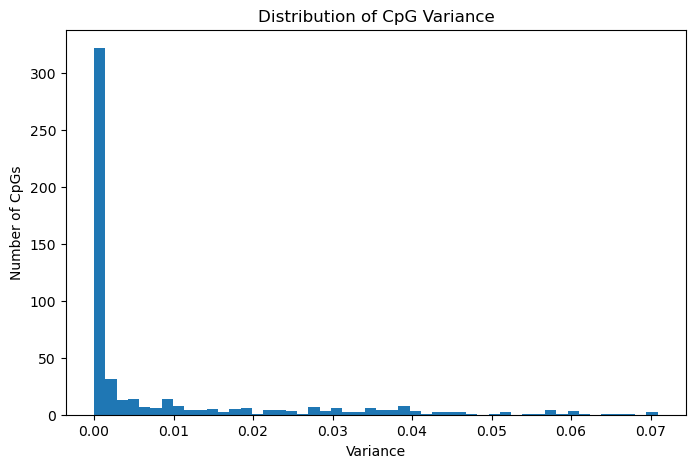

In [56]:

plt.figure(figsize=(8, 5))
plt.hist(cpg_variance, bins=50)
plt.xlabel("Variance")
plt.ylabel("Number of CpGs")
plt.title("Distribution of CpG Variance")
plt.show()

-> Many CpGs with low variance, the major amount far below 0.01, maybe more like 0.001. But since it is difficult to actually see the distribution in the low area with most datapoints -> next zoom in and only look at distribution below different thresholds to get a feeling for the distribution of data there.

In [57]:
# Stretch distribution in low areas (zooming in), where CpGs cluster to better see the actual distribution there

thresholds = [0.1, 0.01, 0.001, 0.0005, 0.0001]
total_cpgs = len(cpg_variance)
variance_counts = pd.DataFrame({
    "Threshold": thresholds,
    "CpGs below thresh": [(cpg_variance < t).sum() for t in thresholds],
    "CpGs above thresh": [(cpg_variance >= t).sum() for t in thresholds],
    "Percentage below (%)": [round((cpg_variance < t).sum() / total_cpgs * 100, 1) for t in thresholds]
})

print(variance_counts)


   Threshold  CpGs below thresh  CpGs above thresh  Percentage below (%)
0     0.1000                526                  0                 100.0
1     0.0100                411                115                  78.1
2     0.0010                301                225                  57.2
3     0.0005                247                279                  47.0
4     0.0001                102                424                  19.4


-> More than half (57.2%) of all CpGs have a variance below .001, just under 50% below .0005.
Low variance in methylation data is a normal phenomenon, but in our case with the selection of the 50 PAM-Genes this probably leads to a particularly low variance: as these Genes are known to play a major role in breastcancer, so they are expected to have higher transcription than an average unfiltered gene set, so methylation should also be lower than usually in these gene set. 

--> feature set is biased toward stable low-methylation sites by construction

-> Our approach to deal with that: in NN model we filter features for variance first before feeding them to the model: meth_variance_threshold=0.0005. We first visually check resulting distributions when filtering the CpGs to throw out very low variance features. Check for beta-values as well as transformed m-values, since they are in the end used in statistical modeling.

#### Check distributions when filtering for high-var CpGs

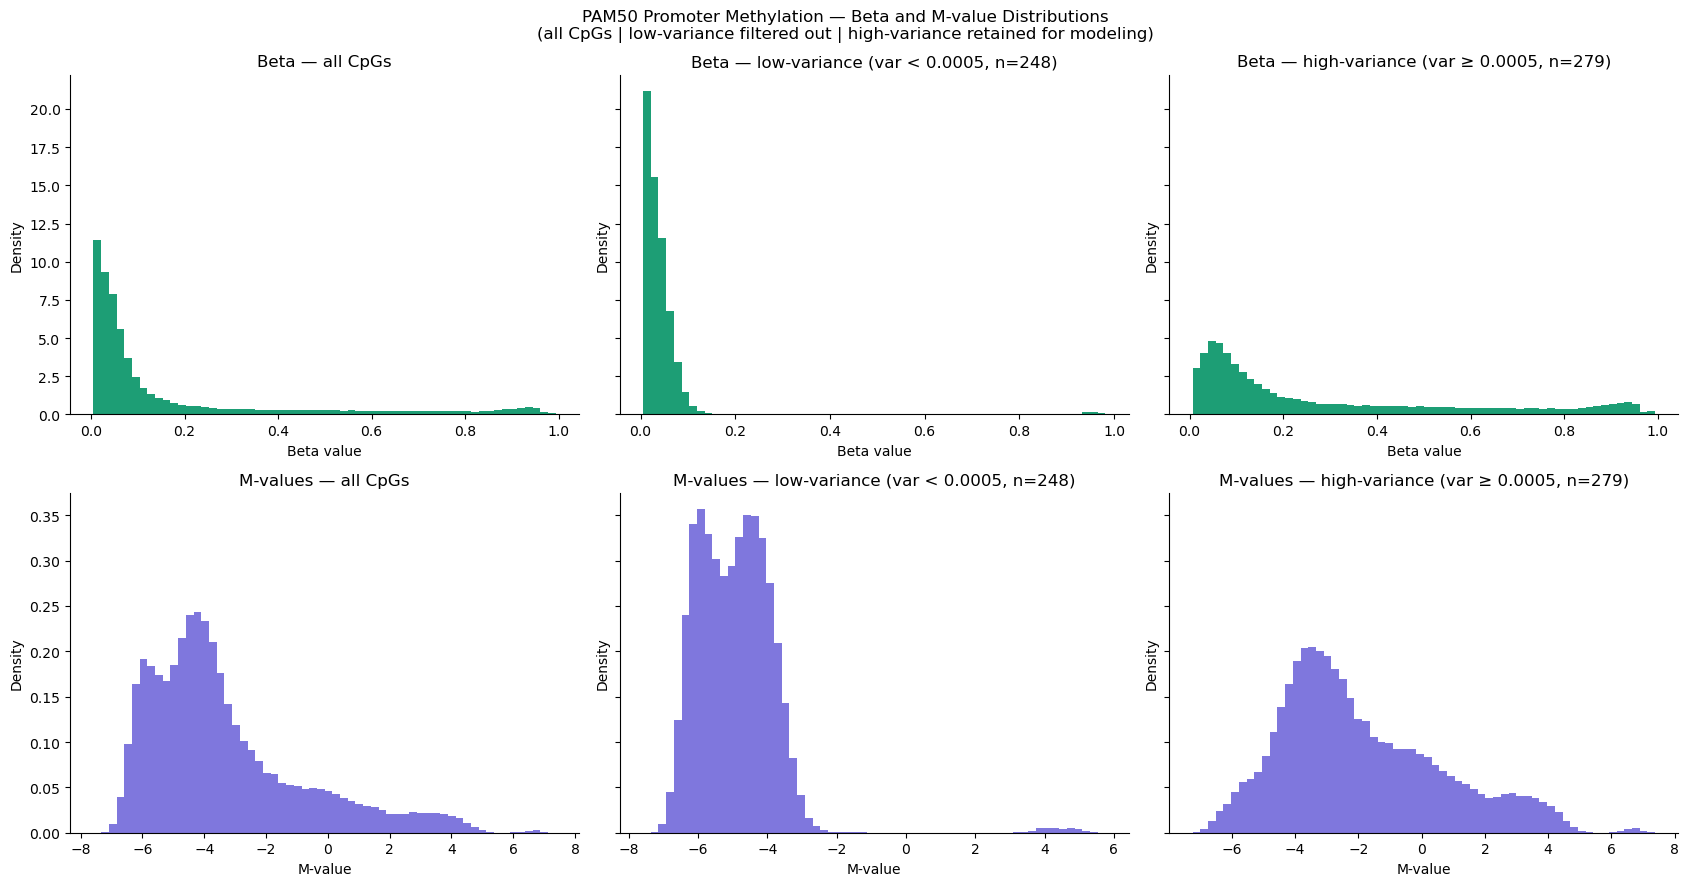

All CpGs:       527
Low-variance:   248 (47.1%) — filtered out
High-variance:  279 (52.9%) — retained for modeling


In [58]:
# Beta vs M-value distribution
def beta_to_m(B):
    B = np.clip(B, 1e-4, 1 - 1e-4)
    return np.log2(B / (1 - B))

all_beta = meth_clean.values.ravel()
all_beta = all_beta[~np.isnan(all_beta)]
all_m = beta_to_m(all_beta)

low_var_cpgs  = meth_clean.columns[meth_clean.var(axis=0) <  0.0005]
high_var_cpgs = meth_clean.columns[meth_clean.var(axis=0) >= 0.0005]

all_beta_low  = meth_clean[low_var_cpgs].values.ravel()
all_beta_low  = all_beta_low[~np.isnan(all_beta_low)]
all_m_low     = beta_to_m(all_beta_low)

all_beta_high = meth_clean[high_var_cpgs].values.ravel()
all_beta_high = all_beta_high[~np.isnan(all_beta_high)]
all_m_high    = beta_to_m(all_beta_high)

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharey="row")

# top row — beta
axes[0, 0].hist(all_beta, bins=60, color="#1D9E75", edgecolor="none", density=True)
axes[0, 0].set_title("Beta — all CpGs")
axes[0, 0].set_xlabel("Beta value")
axes[0, 0].set_ylabel("Density")
axes[0, 0].spines[["top", "right"]].set_visible(False)

axes[0, 1].hist(all_beta_low, bins=60, color="#1D9E75", edgecolor="none", density=True)
axes[0, 1].set_title(f"Beta — low-variance (var < 0.0005, n={len(low_var_cpgs)})")
axes[0, 1].set_xlabel("Beta value")
axes[0, 1].set_ylabel("Density")
axes[0, 1].spines[["top", "right"]].set_visible(False)

axes[0, 2].hist(all_beta_high, bins=60, color="#1D9E75", edgecolor="none", density=True)
axes[0, 2].set_title(f"Beta — high-variance (var ≥ 0.0005, n={len(high_var_cpgs)})")
axes[0, 2].set_xlabel("Beta value")
axes[0, 2].set_ylabel("Density")
axes[0, 2].spines[["top", "right"]].set_visible(False)

# bottom row — M-values
axes[1, 0].hist(all_m, bins=60, color="#7F77DD", edgecolor="none", density=True)
axes[1, 0].set_title("M-values — all CpGs")
axes[1, 0].set_xlabel("M-value")
axes[1, 0].set_ylabel("Density")
axes[1, 0].spines[["top", "right"]].set_visible(False)

axes[1, 1].hist(all_m_low, bins=60, color="#7F77DD", edgecolor="none", density=True)
axes[1, 1].set_title(f"M-values — low-variance (var < 0.0005, n={len(low_var_cpgs)})")
axes[1, 1].set_xlabel("M-value")
axes[1, 1].set_ylabel("Density")
axes[1, 1].spines[["top", "right"]].set_visible(False)

axes[1, 2].hist(all_m_high, bins=60, color="#7F77DD", edgecolor="none", density=True)
axes[1, 2].set_title(f"M-values — high-variance (var ≥ 0.0005, n={len(high_var_cpgs)})")
axes[1, 2].set_xlabel("M-value")
axes[1, 2].set_ylabel("Density")
axes[1, 2].spines[["top", "right"]].set_visible(False)

fig.suptitle("PAM50 Promoter Methylation — Beta and M-value Distributions\n(all CpGs | low-variance filtered out | high-variance retained for modeling)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/beta_vs_mvalue_distribution.png", dpi=300)
plt.show()

print(f"All CpGs:       {len(meth_clean.columns)}")
print(f"Low-variance:   {len(low_var_cpgs)} ({len(low_var_cpgs)/len(meth_clean.columns)*100:.1f}%) — filtered out")
print(f"High-variance:  {len(high_var_cpgs)} ({len(high_var_cpgs)/len(meth_clean.columns)*100:.1f}%) — retained for modeling")

-> beta value distributions show that low varince cpgs are mainly cpgs close to beta of 0. A few are on the other side of the axis, close to 1, but no beta values in the middle area. This is as expected, since usually (in healthy tissue) methylation pattern is clear. Beta value in the middle area, suggesting a mixed methylation pattern, are therefore likely to have high variance.

-> also looking at m-values, filtering for high var cpgs makes distribution more symmetrical.

## Distribution per gene by subtype: Violin plots for key PAM50 genes 

### RNA 

## Key genes: Explanation of Gene Selection for Violin plots

The 8 genes were chosen to cover the main biological axes that are known to distinguish LumA from LumB. This way the panel gives a broad, representative picture of subtype differences across different biological mechanisms — if the data behaves as expected on these key axes, it validates that the cohort is biologically sound before moving to modeling.

- **Hormone receptor axis** → ESR1, PGR
  - both subtypes are hormone receptor positive by definition, so ESR1 differences expected to be small
  - PGR tends to be more strongly expressed in LumA → expect higher PGR in LumA

- **Proliferation axis** → MKI67, BIRC5
  - LumB is clinically defined by higher proliferative activity
  - → expect both significantly higher in LumB

- **HER2 pathway axis** → ERBB2, GRB7
  - co-located on chromosome 17, co-regulated
  - LumB can show HER2 pathway activity without clinical HER2 amplification
  - → expect modest elevation in LumB, signal likely weak

- **Basal marker axis** → KRT5, KRT14
  - normally active in basal-like breast cancer, not luminal subtypes
  - → expect both subtypes to show low expression, with LumB showing slightly less suppression than LumA


**Results**

- **PGR (p < 0.001):** significantly higher in LumA (median 12.66 vs 11.30, diff +1.37), confirming the expected stronger progesterone receptor positivity in LumA.
- **MKI67 (p < 0.001):** significantly higher in LumB (median 12.72 vs 11.37, diff -1.36), consistent with the known higher proliferative activity of LumB.
- **BIRC5 (p < 0.001):** the largest effect among proliferation markers, significantly higher in LumB (median 11.52 vs 10.06, diff -1.46), further supporting the proliferation difference between subtypes.
- **KRT5 (p < 0.001):** significantly higher in LumA (median 11.99 vs 9.01, diff +2.98), the largest absolute difference in the panel. Counterintuitive at first since KRT5 is a basal marker, but LumA retains more residual basal gene expression than LumB in this cohort.
- **KRT14 (p < 0.001):** same pattern as KRT5, significantly higher in LumA (median 11.67 vs 8.46, diff +3.20), the largest effect in the entire panel.
- **ERBB2 (p < 0.05):** weakly but significantly higher in LumA (median 14.38 vs 14.13, diff +0.25). The difference is small and the direction is opposite to the expected LumB enrichment, suggesting ERBB2 expression alone does not cleanly distinguish the subtypes in the luminal group.
- **ESR1 (ns, p = 0.088):** no significant difference between subtypes, consistent with both being ESR1-driven luminal cancers where expression levels are similarly high.
- **GRB7 (ns, p = 0.873):** no subtype difference at all, suggesting HER2 pathway co-regulation via GRB7 is not a distinguishing feature within the luminal group.

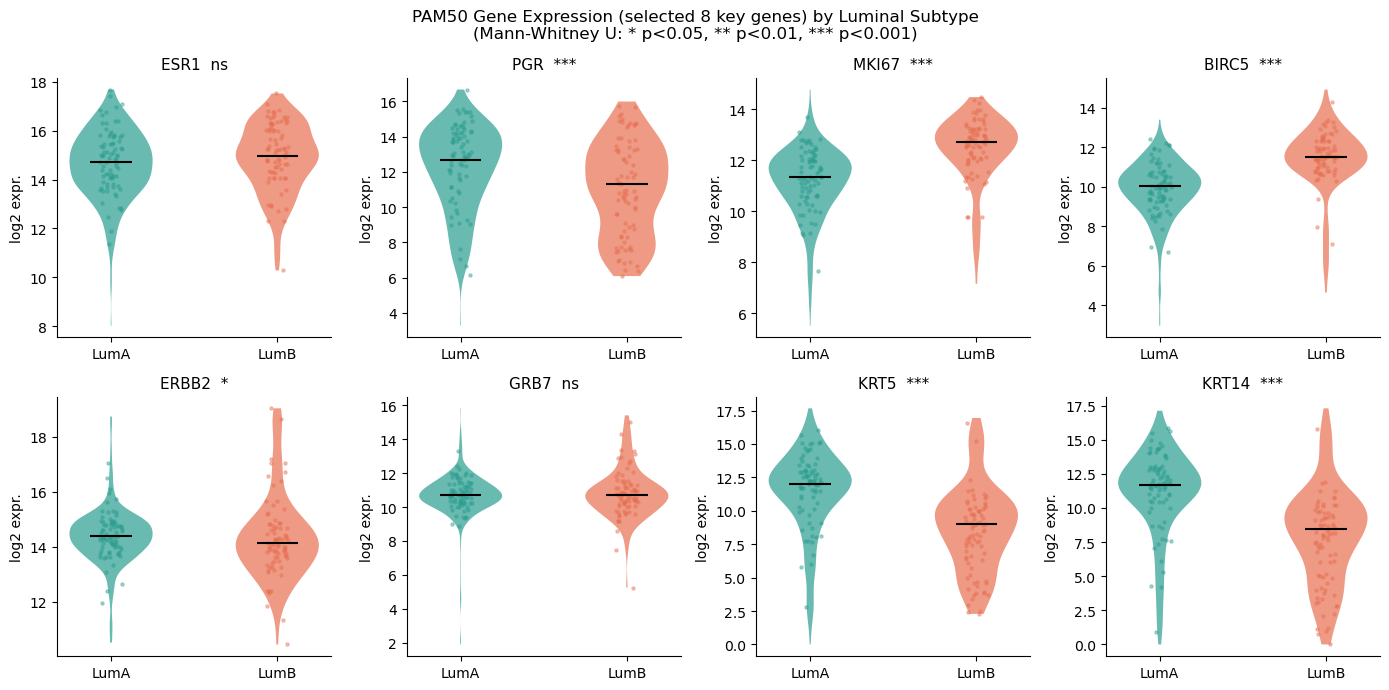

,gene,median_LumA,median_LumB,median_diff,p_value,significance
0,ESR1,14.697,14.957,-0.260,8.761325e-02,ns
1,PGR,12.660,11.295,1.366,2.308797e-06,***
2,MKI67,11.365,12.721,-1.356,1.136699e-26,***
3,BIRC5,10.056,11.518,-1.462,1.353122e-29,***
4,ERBB2,14.383,14.134,0.250,2.212802e-02,*
5,GRB7,10.733,10.694,0.039,8.733843e-01,ns
6,KRT5,11.995,9.011,2.984,7.466739e-20,***
7,KRT14,11.666,8.464,3.202,1.290393e-22,***


In [59]:

# RNA violin plots for key PAM50 genes by subtype
KEY_GENES = ["ESR1", "PGR", "MKI67", "BIRC5", "ERBB2", "GRB7", "KRT5", "KRT14"]
available = [g for g in KEY_GENES if g in rna.columns]

COLORS = {"LumA": "#2a9d8f", "LumB": "#e76f51"}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, gene in zip(axes, available):
    luma = rna.loc[subtype == "LumA", gene].dropna()
    lumb = rna.loc[subtype == "LumB", gene].dropna()

    parts = ax.violinplot([luma, lumb], positions=[0, 1], showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], [COLORS["LumA"], COLORS["LumB"]]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.5)

    rng = np.random.default_rng(42)
    for pos, vals, color in zip([0, 1], [luma, lumb], [COLORS["LumA"], COLORS["LumB"]]):
        idx = rng.choice(len(vals), size=min(80, len(vals)), replace=False)
        jitter = rng.uniform(-0.07, 0.07, size=len(idx))
        ax.scatter(pos + jitter, vals.iloc[idx], s=5, alpha=0.4, color=color)

    _, pval = stats.mannwhitneyu(luma, lumb, alternative="two-sided")
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

    ax.set_title(f"{gene}  {sig}", fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["LumA", "LumB"])
    ax.set_ylabel("log2 expr.")
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(available):]:
    ax.set_visible(False)

fig.suptitle("PAM50 Gene Expression (selected 8 key genes) by Luminal Subtype\n(Mann-Whitney U: * p<0.05, ** p<0.01, *** p<0.001)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/rna_violin_by_subtype.png", dpi=300)
plt.show()


#save summary statistics in case it is needed:
# Summary statistics for RNA violin plot
violin_summary_rows = []
for gene in available:
    luma = rna.loc[subtype == "LumA", gene].dropna()
    lumb = rna.loc[subtype == "LumB", gene].dropna()
    _, pval = stats.mannwhitneyu(luma, lumb, alternative="two-sided")
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    violin_summary_rows.append({
        "gene": gene,
        "median_LumA": round(luma.median(), 3),
        "median_LumB": round(lumb.median(), 3),
        "median_diff": round(luma.median() - lumb.median(), 3),
        "p_value": pval,
        "significance": sig
    })

violin_summary = pd.DataFrame(violin_summary_rows)
violin_summary.to_csv("../results/tables/rna_violin_summary.csv", index=False)
violin_summary


### Methylation

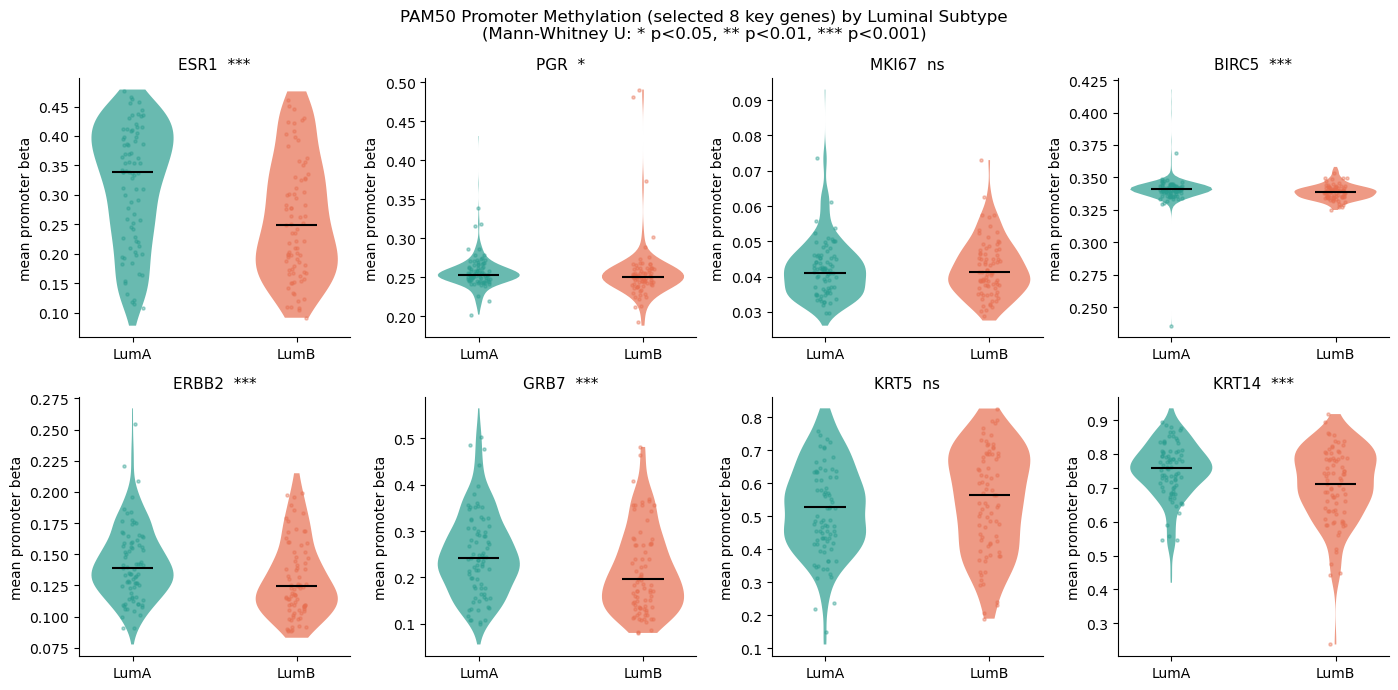

In [60]:

# Methylation violin plots, same 8 genes as the RNA violin panel, so the two are
# directly comparable. Uses mean promoter beta per gene (same as the scatter panel).

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, gene in zip(axes, available):
    cpg_ids = cpg_gene.loc[cpg_gene["gene"] == gene, "cpg"].tolist()
    cpg_ids = [c for c in cpg_ids if c in meth_clean.columns]
    if not cpg_ids:
        ax.set_visible(False)
        continue

    mean_beta = meth_clean[cpg_ids].mean(axis=1)
    luma = mean_beta.loc[subtype.index[subtype == "LumA"]].dropna()
    lumb = mean_beta.loc[subtype.index[subtype == "LumB"]].dropna()

    parts = ax.violinplot([luma, lumb], positions=[0, 1], showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], [COLORS["LumA"], COLORS["LumB"]]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.5)

    rng = np.random.default_rng(42)
    for pos, vals, color in zip([0, 1], [luma, lumb], [COLORS["LumA"], COLORS["LumB"]]):
        idx = rng.choice(len(vals), size=min(80, len(vals)), replace=False)
        jitter = rng.uniform(-0.07, 0.07, size=len(idx))
        ax.scatter(pos + jitter, vals.iloc[idx], s=5, alpha=0.4, color=color)

    _, pval = stats.mannwhitneyu(luma, lumb, alternative="two-sided")
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

    ax.set_title(f"{gene}  {sig}", fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["LumA", "LumB"])
    ax.set_ylabel("mean promoter beta")
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(available):]:
    ax.set_visible(False)

fig.suptitle("PAM50 Promoter Methylation (selected 8 key genes) by Luminal Subtype\n(Mann-Whitney U: * p<0.05, ** p<0.01, *** p<0.001)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/meth_violin_by_subtype.png", dpi=300)
plt.show()

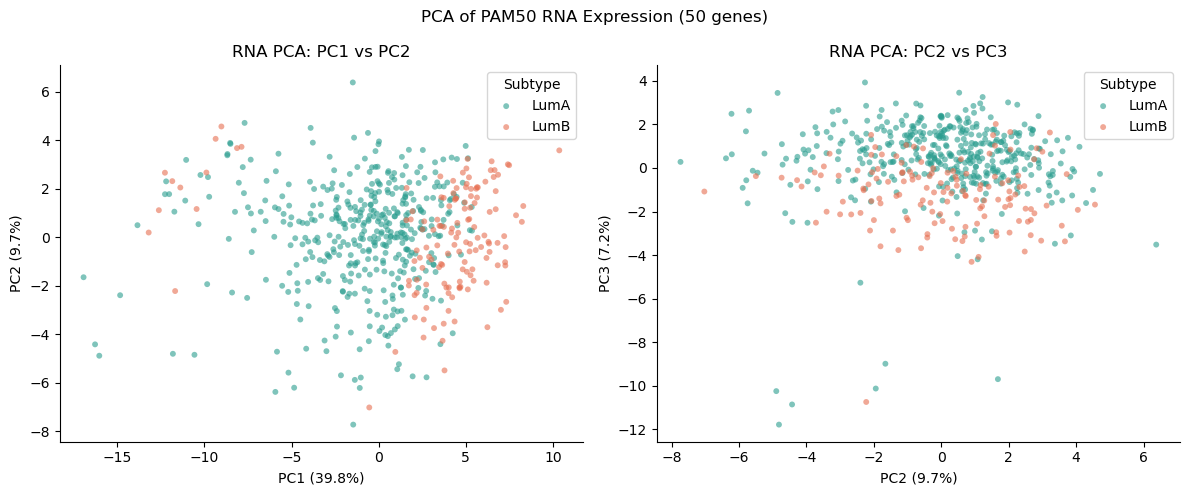

In [61]:

# PCA of RNA features
scaler = StandardScaler()
rna_scaled = scaler.fit_transform(rna)
pca_rna = PCA(n_components=5, random_state=42)
rna_pcs = pca_rna.fit_transform(rna_scaled)
var_rna = pca_rna.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (px, py) in zip(axes, [(0, 1), (1, 2)]):
    for st in ["LumA", "LumB"]:
        mask = (subtype == st).values
        ax.scatter(rna_pcs[mask, px], rna_pcs[mask, py],
                   c=COLORS[st], label=st, s=18, alpha=0.6, edgecolors="none")
    ax.set_xlabel(f"PC{px+1} ({var_rna[px]:.1f}%)")
    ax.set_ylabel(f"PC{py+1} ({var_rna[py]:.1f}%)")
    ax.set_title(f"RNA PCA: PC{px+1} vs PC{py+1}")
    ax.legend(title="Subtype")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("PCA of PAM50 RNA Expression (50 genes)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/rna_pca_by_subtype.png", dpi=300)
plt.show()

pd.DataFrame(
    pca_rna.components_[:3].T,
    index=rna.columns,
    columns=["PC1", "PC2", "PC3"]
).assign(PC1_abs=lambda d: d["PC1"].abs()).sort_values("PC1_abs", ascending=False).drop(columns="PC1_abs").to_csv(
    "../results/tables/rna_pca_loadings.csv"
)

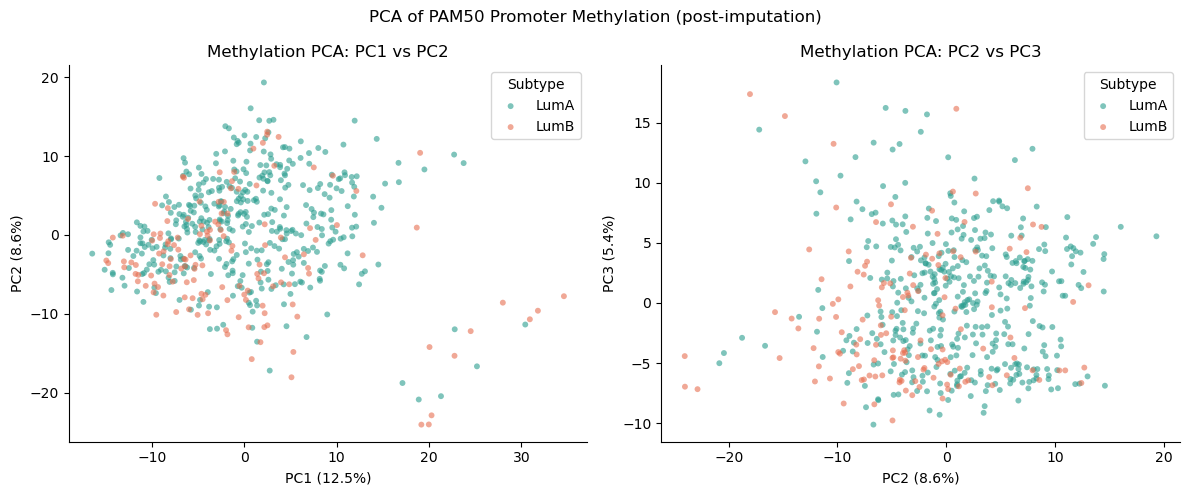

In [62]:

# PCA of methylation features (post-imputation)

pca_meth = PCA(n_components=5, random_state=42)
meth_pcs = pca_meth.fit_transform(meth_scaled)
var_meth = pca_meth.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (px, py) in zip(axes, [(0, 1), (1, 2)]):
    for st in ["LumA", "LumB"]:
        mask = (subtype == st).values
        ax.scatter(meth_pcs[mask, px], meth_pcs[mask, py],
                   c=COLORS[st], label=st, s=18, alpha=0.6, edgecolors="none")
    ax.set_xlabel(f"PC{px+1} ({var_meth[px]:.1f}%)")
    ax.set_ylabel(f"PC{py+1} ({var_meth[py]:.1f}%)")
    ax.set_title(f"Methylation PCA: PC{px+1} vs PC{py+1}")
    ax.legend(title="Subtype")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("PCA of PAM50 Promoter Methylation (post-imputation)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/meth_pca_by_subtype.png", dpi=300)
plt.show()

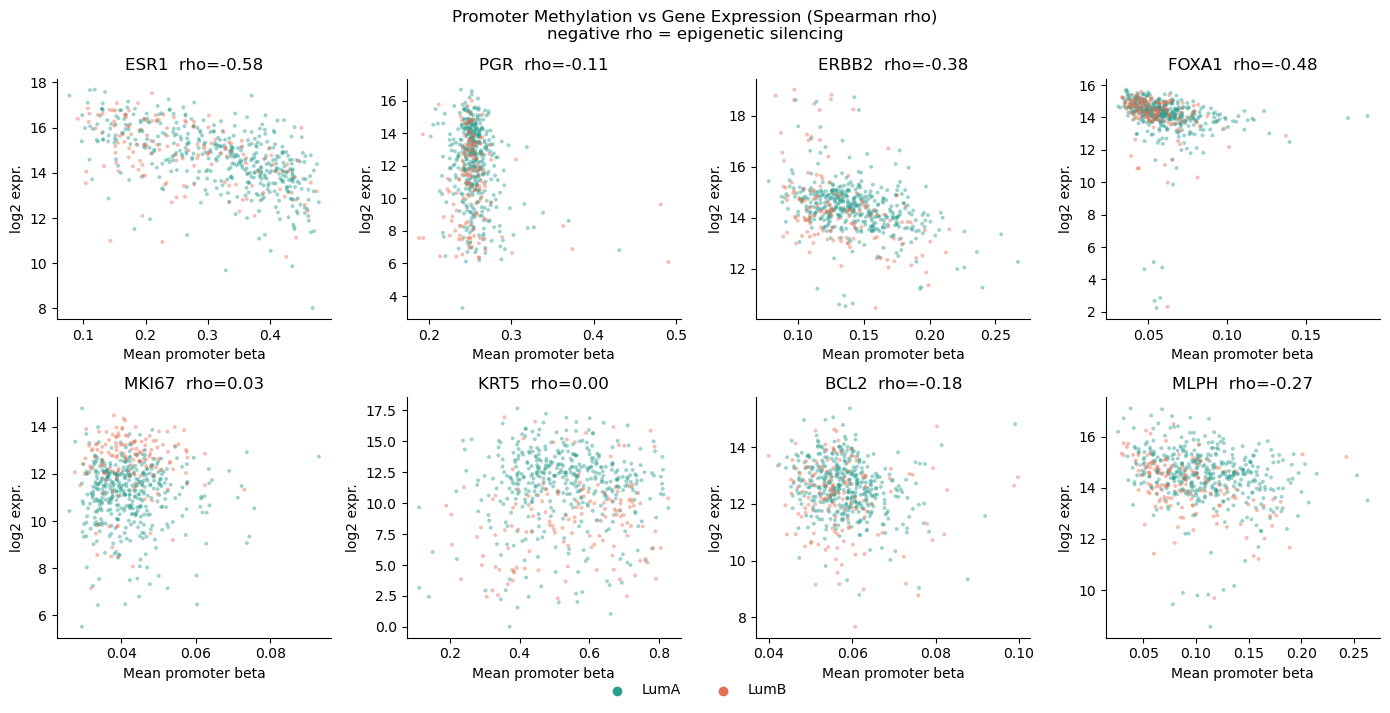

In [63]:

# Meth vs RNA scatter for a selection of key genes (multi-gene panel)
# uses cpg_gene_map to get per-gene mean promoter beta
SCATTER_GENES = ["ESR1", "PGR", "ERBB2", "FOXA1", "MKI67", "KRT5", "BCL2", "MLPH"]
available_scatter = [g for g in SCATTER_GENES if g in rna.columns]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
n_plotted = 0

for ax, gene in zip(axes, available_scatter):
    cpg_ids = cpg_gene.loc[cpg_gene["gene"] == gene, "cpg"].tolist()
    cpg_ids = [c for c in cpg_ids if c in meth_clean.columns]
    if not cpg_ids:
        ax.set_visible(False)
        continue

    mean_beta = meth_clean[cpg_ids].mean(axis=1)
    both = pd.DataFrame({"beta": mean_beta, "rna": rna[gene]}).dropna()
    rho, pval = stats.spearmanr(both["beta"], both["rna"])

    for st in ["LumA", "LumB"]:
        mask = (subtype.loc[both.index] == st).values
        ax.scatter(both.loc[mask, "beta"], both.loc[mask, "rna"],
                   c=COLORS[st], s=8, alpha=0.45, label=st, edgecolors="none")

    ax.set_xlabel("Mean promoter beta")
    ax.set_ylabel("log2 expr.")
    ax.set_title(f"{gene}  rho={rho:.2f}")
    ax.spines[["top", "right"]].set_visible(False)
    n_plotted += 1

for ax in axes[n_plotted:]:
    ax.set_visible(False)

handles = [plt.scatter([], [], c=COLORS[s], label=s) for s in ["LumA", "LumB"]]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Promoter Methylation vs Gene Expression (Spearman rho)\nnegative rho = epigenetic silencing", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/meth_vs_rna_scatter_panel.png", dpi=300, bbox_inches="tight")
plt.show()

c:\Users\laral\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


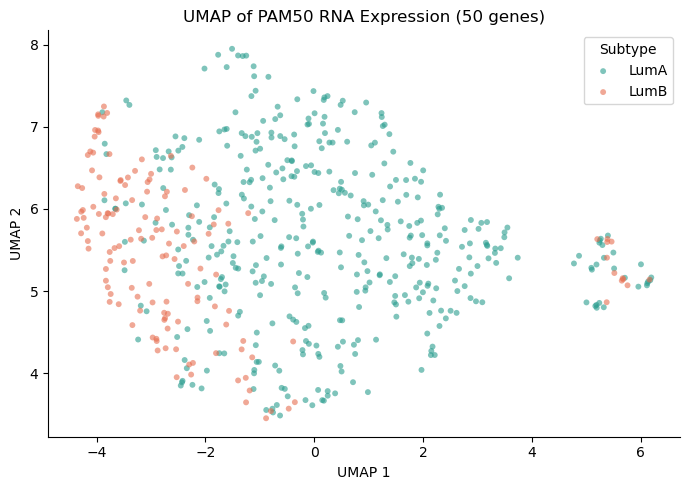

In [64]:

# UMAP of RNA features
reducer_rna = umap.UMAP(n_components=2, random_state=42)
rna_umap = reducer_rna.fit_transform(rna_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
for st in ["LumA", "LumB"]:
    mask = (subtype == st).values
    ax.scatter(rna_umap[mask, 0], rna_umap[mask, 1],
               c=COLORS[st], label=st, s=18, alpha=0.6, edgecolors="none")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of PAM50 RNA Expression (50 genes)")
ax.legend(title="Subtype")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/rna_umap_by_subtype.png", dpi=300)
plt.show()

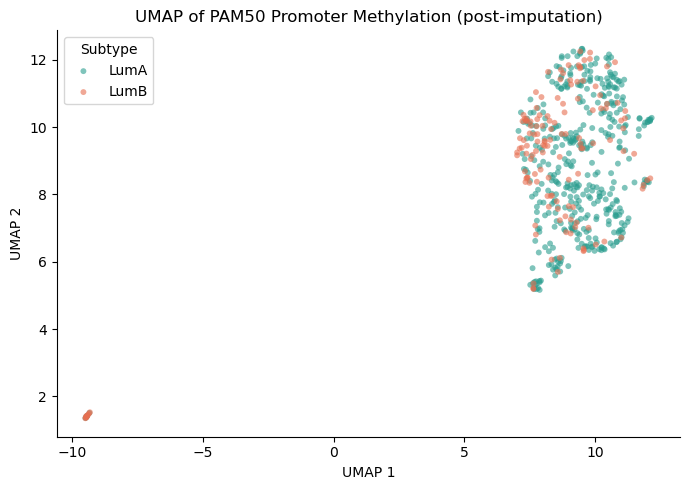

In [67]:

# UMAP of methylation features (post-imputation)
reducer_meth = umap.UMAP(n_components=2)
meth_umap = reducer_meth.fit_transform(meth_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
for st in ["LumA", "LumB"]:
    mask = (subtype == st).values
    ax.scatter(meth_umap[mask, 0], meth_umap[mask, 1],
               c=COLORS[st], label=st, s=18, alpha=0.6, edgecolors="none")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of PAM50 Promoter Methylation (post-imputation)")
ax.legend(title="Subtype")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/meth_umap_by_subtype.png", dpi=300)
plt.show()

In [66]:

# Mann-Whitney U test for ALL 50 PAM50 genes (not just the 8 shown in the violin
# panel above), with Benjamini-Hochberg correction since we're testing 50 genes
# at once. The 8-gene violin panel is illustrative, this table covers everything.

def bh_qvalues(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order] * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out

rows = []
for gene in rna.columns:
    luma = rna.loc[subtype == "LumA", gene].dropna()
    lumb = rna.loc[subtype == "LumB", gene].dropna()
    stat, pval = stats.mannwhitneyu(luma, lumb, alternative="two-sided")
    rows.append({"gene": gene, "p_value": pval, "median_LumA": luma.median(), "median_LumB": lumb.median()})

rna_sig = pd.DataFrame(rows)
rna_sig["q_value"] = bh_qvalues(rna_sig["p_value"])
rna_sig = rna_sig.sort_values("p_value")
rna_sig.to_csv("../results/tables/rna_subtype_significance_all_genes.csv", index=False)

print(f"Significant genes (q < 0.05): {(rna_sig['q_value'] < 0.05).sum()} / {len(rna_sig)}")
rna_sig.head(10)

Significant genes (q < 0.05): 38 / 50


,gene,p_value,median_LumA,median_LumB,q_value
26,CEP55,1.891641e-36,9.285214,10.670005,9.458207e-35
4,NDC80,9.200568e-33,8.687427,9.956393,2.300142e-31
43,EXO1,3.426074e-32,8.452650,9.973964,5.710124e-31
3,UBE2T,3.513673e-31,9.364746,10.803114,4.392091e-30
31,NUF2,1.101372e-30,8.837116,10.237707,1.039820e-29
37,MELK,1.247784e-30,8.917445,10.367866,1.039820e-29
6,BIRC5,1.353122e-29,10.055742,11.518122,9.665155e-29
23,CCNB1,1.837489e-29,10.773373,11.906737,1.085157e-28
44,UBE2C,1.953282e-29,9.689291,11.415960,1.085157e-28
10,CDC6,1.097633e-28,9.203037,10.871669,5.488163e-28


In [71]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

# biological axis per PAM50 gene
pam50_axes = {
    "ESR1": "Hormone", "PGR": "Hormone", "FOXA1": "Hormone",
    "MLPH": "Hormone", "NAT1": "Hormone", "BAG1": "Hormone",
    "BLVRA": "Hormone", "SFRP1": "Hormone", "BCL2": "Hormone",
    "CXXC5": "Hormone", "SLC39A6": "Hormone", "GPR160": "Hormone",
    "ERBB2": "HER2", "GRB7": "HER2", "FGFR4": "HER2",
    "MKI67": "Prolif.", "BIRC5": "Prolif.", "CCNB1": "Prolif.",
    "CCNE1": "Prolif.", "CDC20": "Prolif.", "CDC6": "Prolif.",
    "ANLN": "Prolif.", "MELK": "Prolif.", "MYBL2": "Prolif.",
    "MMP11": "Prolif.", "UBE2C": "Prolif.", "UBE2T": "Prolif.",
    "PTTG1": "Prolif.", "EXO1": "Prolif.", "NUF2": "Prolif.",
    "NDC80": "Prolif.", "KIF2C": "Prolif.", "CENPF": "Prolif.",
    "CEP55": "Prolif.", "TYMS": "Prolif.", "RRM2": "Prolif.",
    "ORC6": "Prolif.", "MDM2": "Prolif.", "MYC": "Prolif.",
    "KRT5": "Basal", "KRT14": "Basal", "KRT17": "Basal",
    "FOXC1": "Basal", "MIA": "Basal", "PHGDH": "Basal",
    "EGFR": "Basal", "CDH3": "Basal", "ACTR3B": "Basal",
    "MAPT": "Other", "TMEM45B": "Other",
}

# --- gene expression by subtype ---
expr_rows = []
for gene in rna.columns:
    luma = rna.loc[subtype == "LumA", gene].dropna()
    lumb = rna.loc[subtype == "LumB", gene].dropna()
    _, pval = stats.mannwhitneyu(luma, lumb, alternative="two-sided")
    expr_rows.append({
        "gene": gene,
        "expr_median_LumA": round(luma.median(), 3),
        "expr_median_LumB": round(lumb.median(), 3),
        "expr_abs_diff": round(abs(luma.median() - lumb.median()), 3),
        "expr_pval": round(pval, 4),
    })
expr_df = pd.DataFrame(expr_rows)
expr_df["expr_qval"] = multipletests(expr_df["expr_pval"], method="fdr_bh")[1].round(4)
expr_df["expr_sig"] = expr_df["expr_qval"].apply(
    lambda q: "***" if q < 0.001 else "**" if q < 0.01 else "*" if q < 0.05 else "ns")

# --- mean promoter methylation by subtype + SD across CpGs ---
meth_rows = []
for gene in rna.columns:
    cpg_ids = cpg_gene.loc[cpg_gene["gene"] == gene, "cpg"].tolist()
    cpg_ids = [c for c in cpg_ids if c in meth_clean.columns]
    if not cpg_ids:
        meth_rows.append({
            "gene": gene, "n_cpgs": 0,
            "meth_mean_LumA": None, "meth_mean_LumB": None,
            "meth_abs_diff": None, "meth_pval": None, "cpg_sd": None,
        })
        continue
    mean_beta = meth_clean[cpg_ids].mean(axis=1)
    luma_m = mean_beta.loc[subtype.index[subtype == "LumA"]].dropna()
    lumb_m = mean_beta.loc[subtype.index[subtype == "LumB"]].dropna()
    _, pval = stats.mannwhitneyu(luma_m, lumb_m, alternative="two-sided")
    cpg_means = meth_clean[cpg_ids].mean(axis=0)
    meth_rows.append({
        "gene": gene,
        "n_cpgs": len(cpg_ids),
        "meth_mean_LumA": round(luma_m.mean(), 3),
        "meth_mean_LumB": round(lumb_m.mean(), 3),
        "meth_abs_diff": round(abs(luma_m.mean() - lumb_m.mean()), 3),
        "meth_pval": round(pval, 4),
        "cpg_sd": round(cpg_means.std(), 4),
    })
meth_df = pd.DataFrame(meth_rows)
valid_meth = meth_df["meth_pval"].notna()
meth_df.loc[valid_meth, "meth_qval"] = multipletests(
    meth_df.loc[valid_meth, "meth_pval"], method="fdr_bh")[1].round(4)
meth_df["meth_sig"] = meth_df["meth_qval"].apply(
    lambda q: "***" if q < 0.001 else "**" if q < 0.01 else "*" if q < 0.05 else "ns"
    if pd.notna(q) else None)

# --- methylation-expression Spearman correlation ---
corr_rows = []
for gene in rna.columns:
    cpg_ids = cpg_gene.loc[cpg_gene["gene"] == gene, "cpg"].tolist()
    cpg_ids = [c for c in cpg_ids if c in meth_clean.columns]
    if not cpg_ids:
        corr_rows.append({"gene": gene, "spearman_rho": None,
                          "corr_pval": None})
        continue
    mean_beta = meth_clean[cpg_ids].mean(axis=1)
    both = pd.DataFrame({"beta": mean_beta, "rna": rna[gene]}).dropna()
    rho, pval = stats.spearmanr(both["beta"], both["rna"])
    corr_rows.append({
        "gene": gene,
        "spearman_rho": round(rho, 3),
        "corr_pval": round(pval, 4),
    })
corr_df = pd.DataFrame(corr_rows)
valid_corr = corr_df["corr_pval"].notna()
corr_df.loc[valid_corr, "corr_qval"] = multipletests(
    corr_df.loc[valid_corr, "corr_pval"], method="fdr_bh")[1].round(4)
corr_df["corr_sig"] = corr_df["corr_qval"].apply(
    lambda q: "***" if q < 0.001 else "**" if q < 0.01 else "*" if q < 0.05 else "ns"
    if pd.notna(q) else None)

# --- merge and add axis ---
gene_table = (expr_df
    .merge(meth_df, on="gene")
    .merge(corr_df, on="gene")
    .sort_values("gene")
    .reset_index(drop=True)
)
gene_table.insert(1, "Axis", gene_table["gene"].map(pam50_axes).fillna("Other"))

gene_table.columns = [
    "Gene", "Axis",
    "Expr LumA", "Expr LumB", "Expr |diff|", "Expr p", "Expr q", "Expr sig",
    "N CpGs",
    "Meth LumA", "Meth LumB", "Meth |diff|", "Meth p", "CpG SD", "Meth q", "Meth sig",
    "Spearman rho", "Corr p", "Corr q", "Corr sig",
]

gene_table.to_csv("../results/tables/gene_summary_table.csv", index=False)
print(gene_table.to_string(index=False))

   Gene    Axis  Expr LumA  Expr LumB  Expr |diff|  Expr p  Expr q Expr sig  N CpGs  Meth LumA  Meth LumB  Meth |diff|  Meth p  CpG SD  Meth q Meth sig  Spearman rho  Corr p  Corr q Corr sig
 ACTR3B   Basal      8.997      9.002        0.005  0.7240  0.8044       ns       6      0.229      0.230        0.001  0.4118  0.3231  0.5045       ns        -0.248  0.0000  0.0000      ***
   ANLN Prolif.     10.030     11.412        1.382  0.0000  0.0000      ***       6      0.076      0.073        0.003  0.0047  0.0845  0.0128        *        -0.170  0.0000  0.0000      ***
   BAG1 Hormone     12.350     12.038        0.312  0.0001  0.0002      ***       6      0.203      0.205        0.002  0.0141  0.3600  0.0300        *        -0.159  0.0002  0.0004      ***
   BCL2 Hormone     12.606     12.385        0.221  0.0043  0.0061       **      27      0.058      0.057        0.001  0.0071  0.0428  0.0166        *        -0.177  0.0000  0.0000      ***
  BIRC5 Prolif.     10.056     11.518        

In [70]:
# genes where methylation differs between subtypes but expression does not
# = strongest evidence for subtype-specific epigenetic silencing (RQ1)

silencing_genes = gene_table[
    (gene_table["Expr sig"] == "ns") &          # no expression difference
    (gene_table["Meth sig"].isin(["*", "**", "***"])) &  # methylation differs
    (gene_table["Corr sig"].isin(["*", "**", "***"])) &  # correlation significant
    (gene_table["Spearman rho"] < 0)             # negative = silencing direction
].copy()

print(f"Genes with subtype-specific epigenetic silencing pattern: {len(silencing_genes)}")
print(silencing_genes[["Gene", "Axis", "Expr sig", "Meth LumA", "Meth LumB",
                         "Meth |diff|", "Meth sig", "Spearman rho", "Corr sig"]].to_string(index=False))

silencing_genes.to_csv("../results/tables/subtype_specific_silencing_genes.csv", index=False)

Genes with subtype-specific epigenetic silencing pattern: 5
  Gene    Axis Expr sig  Meth LumA  Meth LumB  Meth |diff| Meth sig  Spearman rho Corr sig
  ESR1 Hormone       ns      0.320      0.264        0.056      ***        -0.584      ***
 FOXA1 Hormone       ns      0.061      0.055        0.006       **        -0.482      ***
GPR160 Hormone       ns      0.261      0.235        0.026      ***        -0.390      ***
  GRB7    HER2       ns      0.251      0.215        0.036      ***        -0.317      ***
 PHGDH   Basal       ns      0.331      0.350        0.019        *        -0.276      ***


### Data quality: Check batch effects

#### Methylation

Unique TSS codes in methylation data: 39


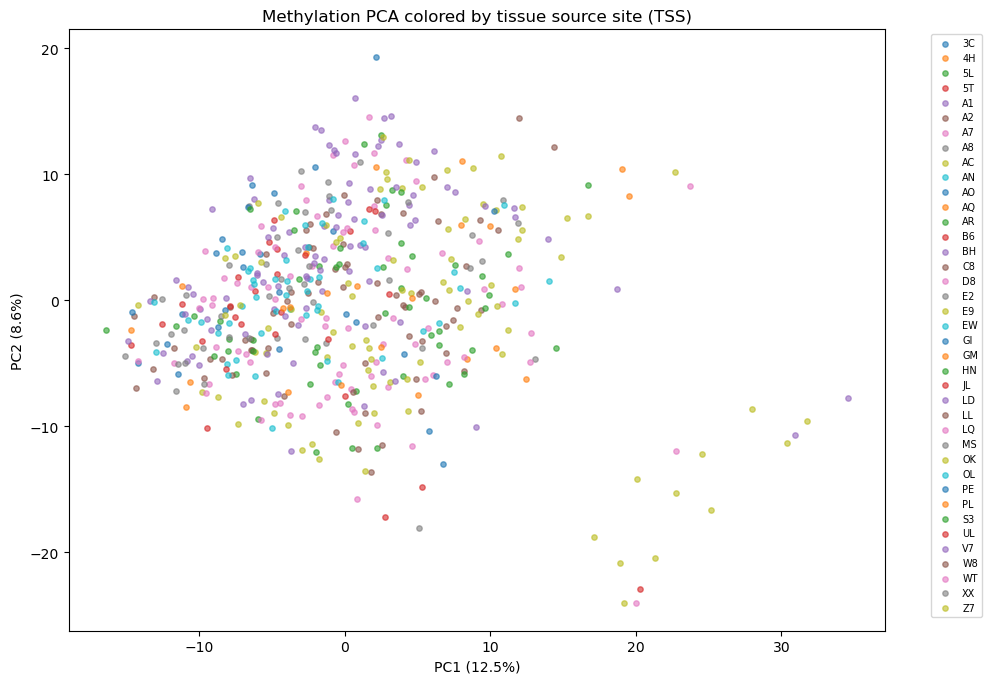

Batch R² (TSS, PC1-10): 0.007


In [84]:
# Methylation

tss = pd.Series(
    [pid.split("-")[1] for pid in meth_clean.index],
    index=meth_clean.index,
    name="TSS"
)
print(f"Unique TSS codes in methylation data: {tss.nunique()}")
#print(tss.value_counts())

# PCA colored by TSS
pca = PCA(n_components=10, random_state=42)
pcs = pca.fit_transform(StandardScaler().fit_transform(meth_clean))

fig, ax = plt.subplots(figsize=(10, 7))
for site in tss.unique():
    mask = (tss == site).values
    ax.scatter(pcs[mask, 0], pcs[mask, 1], label=site, s=15, alpha=0.6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Methylation PCA colored by tissue source site (TSS)")
ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/figures/meth_pca_batch_check.png", dpi=300)
plt.show()

# quantitative batch R2
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

tss_encoded = LabelEncoder().fit_transform(tss)

r2_per_pc = []
for i in range(10):
    pc = pcs[:, i].reshape(-1, 1)
    r2 = LinearRegression().fit(
        tss_encoded.reshape(-1, 1), pc
    ).score(tss_encoded.reshape(-1, 1), pc)
    r2_per_pc.append(r2)

batch_r2 = np.mean(r2_per_pc)
print(f"Batch R² (TSS, PC1-10): {batch_r2:.3f}") # Interpretation: < 0.1 = acceptable, > 0.2 = concerning

#### RNA

Unique TSS codes in RNA data: 39


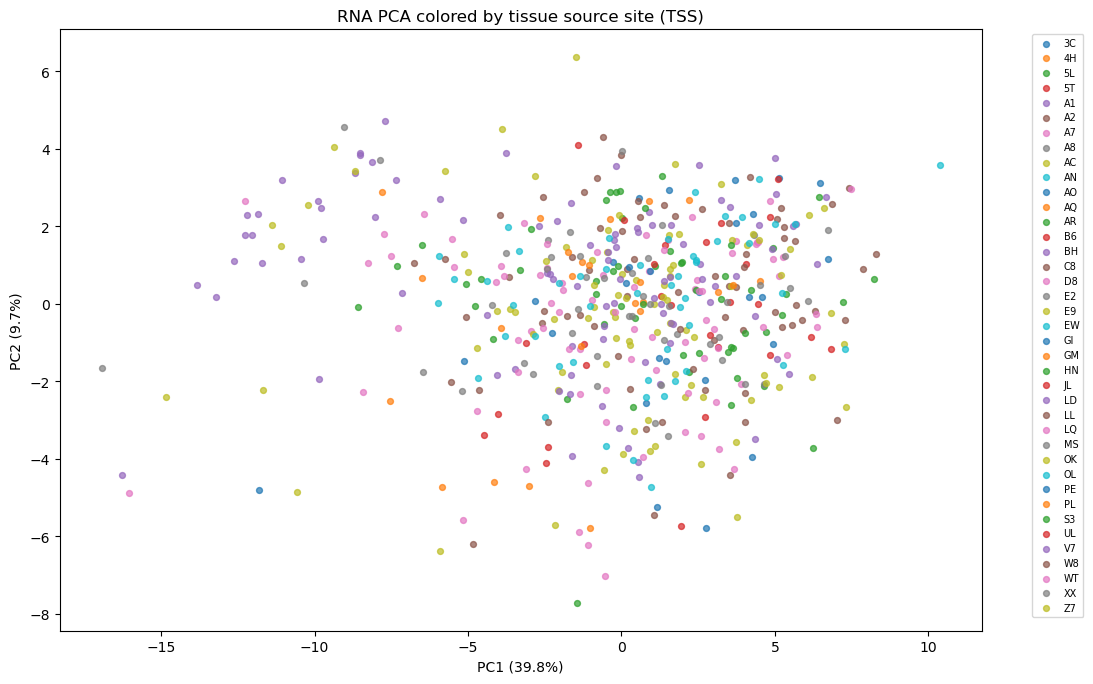


Batch R² (TSS, PC1-10): 0.010


In [85]:
# RNA

tss_rna = pd.Series(
    [pid.split("-")[1] for pid in rna.index],
    index=rna.index,
    name="TSS"
)
print(f"Unique TSS codes in RNA data: {tss_rna.nunique()}")
#print(tss_rna.value_counts())

# PCA colored by TSS
scaler_rna_batch = StandardScaler()
rna_scaled_batch = scaler_rna_batch.fit_transform(rna)
pca_rna_batch = PCA(n_components=10, random_state=42)
pcs_rna = pca_rna_batch.fit_transform(rna_scaled_batch)
var_rna_batch = pca_rna_batch.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(11, 7))
for site in tss_rna.unique():
    mask = (tss_rna == site).values
    ax.scatter(pcs_rna[mask, 0], pcs_rna[mask, 1],
               label=site, s=18, alpha=0.7)
ax.set_xlabel(f"PC1 ({var_rna_batch[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_rna_batch[1]:.1f}%)")
ax.set_title("RNA PCA colored by tissue source site (TSS)")
ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/figures/rna_pca_batch_check.png", dpi=300)
plt.show()

# quantitative batch R²
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

tss_rna_encoded = LabelEncoder().fit_transform(tss_rna)

r2_per_pc_rna = []
for i in range(10):
    pc = pcs_rna[:, i].reshape(-1, 1)
    r2 = LinearRegression().fit(
        tss_rna_encoded.reshape(-1, 1), pc
    ).score(tss_rna_encoded.reshape(-1, 1), pc)
    r2_per_pc_rna.append(r2)

batch_r2_rna = np.mean(r2_per_pc_rna)
print(f"\nBatch R² (TSS, PC1-10): {batch_r2_rna:.3f}") 

### Batch Effect Check

To assess whether technical batch effects from different TCGA collection sites 
influenced the methylation or expression data, we extracted the tissue source site (TSS) code 
from each patient barcode and examined its relationship with the methylation as well as RNA PCA.

(The PCA colored by TSS shows no visible clustering by site — patients from all 
37 tissue source sites are intermixed throughout the PC1/PC2 space.)? 
The quantitative batch R² (variance in PC1–10 explained by TSS) was 0.007, well below the 0.1 
threshold considered acceptable. This confirms that no meaningful batch effects 
are present in the methylation data and no batch correction was necessary.

The RNA data (also shows no visible clustering)? and is with a batch R² of 0.010 below the threshold, confirming no batch correction was required.

In [86]:
clinical = pd.read_csv("../data/processed/clinical_luminal_brca.csv")
print(clinical.columns.tolist())
print(clinical.head())

['patient', 'BRCA_Subtype_PAM50', 'vital_status', 'year_of_death', 'days_to_death', 'days_to_last_follow_up']
        patient BRCA_Subtype_PAM50 vital_status  year_of_death  days_to_death  \
0  TCGA-3C-AAAU               LumA        Alive            NaN            NaN   
1  TCGA-3C-AALJ               LumB        Alive            NaN            NaN   
2  TCGA-3C-AALK               LumA        Alive            NaN            NaN   
3  TCGA-4H-AAAK               LumA        Alive            NaN            NaN   
4  TCGA-5L-AAT0               LumA        Alive            NaN            NaN   

   days_to_last_follow_up  
0                  4047.0  
1                  1474.0  
2                  1448.0  
3                   348.0  
4                  1477.0  
